# Data Preprocessing

Data preprocessing dilakukan untuk menyiapkan dataset sebelum masuk ke tahap feature engineering dan modeling. Pada tahap ini dilakukan transformasi data, encoding, dan feature scaling berdasarkan hasil exploratory data analysis (EDA).

# 1. Import Library

In [81]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset

In [82]:
# membaca dataset hasil wrangling
df = pd.read_csv('../data/wrangled_data.csv')

In [83]:
# menampilkan 5 data pertama
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2021-01-01,store_1,item_1,36,21.3,0,4,1
1,2021-01-02,store_1,item_1,36,21.3,0,5,1
2,2021-01-03,store_1,item_1,35,21.3,0,6,1
3,2021-01-04,store_1,item_1,41,21.3,0,0,1
4,2021-01-05,store_1,item_1,53,21.3,0,1,1


# 3. Menampilkan Informasi Dataset

In [84]:
# informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      54750 non-null  object 
 1   store_id  54750 non-null  object 
 2   item_id   54750 non-null  object 
 3   sales     54750 non-null  int64  
 4   price     54750 non-null  float64
 5   promo     54750 non-null  int64  
 6   weekday   54750 non-null  int64  
 7   month     54750 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [85]:
# statistik deskriptif
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,29.877881,56.077581,0.099233,3.005479,6.526027
std,14.689005,24.102496,0.298977,2.000467,3.447883
min,0.000000,12.200000,0.000000,0.000000,1.000000
25%,19.000000,37.620000,0.000000,1.000000,4.000000
50%,28.000000,58.620000,0.000000,3.000000,7.000000
75%,39.000000,76.300000,0.000000,5.000000,10.000000
max,114.000000,99.990000,1.000000,6.000000,12.000000


In [86]:
# statistik deskriptif
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,29.877881,56.077581,0.099233,3.005479,6.526027
std,14.689005,24.102496,0.298977,2.000467,3.447883
min,0.000000,12.200000,0.000000,0.000000,1.000000
25%,19.000000,37.620000,0.000000,1.000000,4.000000
50%,28.000000,58.620000,0.000000,3.000000,7.000000
75%,39.000000,76.300000,0.000000,5.000000,10.000000
max,114.000000,99.990000,1.000000,6.000000,12.000000


# 4. Menampilkan Kolom Numerik

In [87]:
# memilih kolom numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_cols

Index(['sales', 'price', 'promo', 'weekday', 'month'], dtype='object')

# 5. Handling Outlier

Berdasarkan hasil exploratory data analysis (EDA), ditemukan beberapa outlier pada variabel penjualan. Namun jumlah outlier relatif kecil dan masih merepresentasikan kondisi data yang valid sehingga tidak dilakukan penghapusan data outlier.

<function matplotlib.pyplot.show(close=None, block=None)>

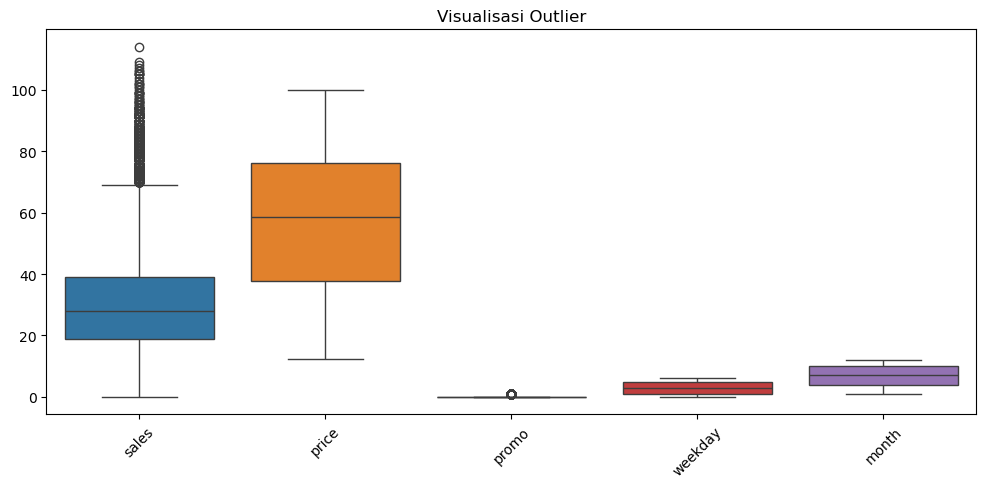

In [88]:
# visualisasi outlier
plt.figure(figsize=(12,5))
sns.boxplot(data=df.select_dtypes(include=np.number))

plt.title('Visualisasi Outlier')
plt.xticks(rotation=45)
plt.show

In [89]:
# Handling outlier menggunakan IQR
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data
df = df[(df['sales'] >= lower_bound) & (df['sales'] <= upper_bound)]

Insight:
- Outlier tidak dihapus karena masih merepresentasikan kondisi penjualan yang valid.
- Metode IQR digunakan untuk mengurangi pengaruh nilai ekstrem sehingga distribusi data menjadi lebih stabil.

# 6. Feature Engineering

Tahap feature engineering dilakukan untuk menghasilkan fitur yang lebih informatif sehingga model dapat memahami pola data dengan lebih baik.

In [90]:
# Mengubah kolom date menjadi datetime
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

    # Membuat fitur waktu
    df['year'] = df['date'].dt.year
    df['day'] = df['date'].dt.day

Insight:
- Feature extraction dari data waktu membantu model mengenali pola musiman, tren bulanan, maupun pola harian.

In [91]:
# Feature Creation: Membuat variabel revenue
df['revenue'] = df['sales'] * df['price']

Insight:
- Pada tahap feature creation, dilakukan pembentukan variabel baru revenue yang merupakan hasil perkalian antara variabel sales dan price. Penambahan variabel revenue bertujuan untuk memperkaya informasi pada dataset sehingga analisis tidak hanya berfokus pada jumlah produk yang terjual, tetapi juga pada nilai pendapatan yang dihasilkan.

In [92]:
# Melakukan Label Encoding pada item_id
label_encoder = LabelEncoder()
df['item_id'] = label_encoder.fit_transform(df['item_id'])
df[['item_id']].head()

,item_id
0,0
1,0
2,0
3,0
4,0


In [93]:
# Menghapus kolom store_id
df = df.drop(columns=['store_id'])

In [94]:
# Menyimpan dataset sebelum scaling
df.to_csv('preprocessed_dataset.csv', index=False)

print("Dataset sebelum scaling berhasil disimpan!")

Dataset sebelum scaling berhasil disimpan!


Insight:
- Dataset hasil preprocessing disimpan sebelum dilakukan proses feature scaling agar nilai setiap variabel tetap berada dalam satuan aslinya. Dataset ini digunakan untuk kebutuhan analisis bisnis, pengembangan dashboard, dan A/B Testing, karena nilai seperti sales, price, dan revenue masih dapat diinterpretasikan secara langsung oleh pengguna. Dengan demikian, hasil visualisasi maupun pengujian statistik tetap merepresentasikan kondisi bisnis yang sebenarnya.

# 7. Feature Scaling

In [95]:
# Memilih fitur numerik
numeric_cols = df.select_dtypes(include=np.number).columns

# Menampilkan fitur numerik
numeric_cols

Index(['item_id', 'sales', 'price', 'promo', 'weekday', 'month', 'year', 'day',
       'revenue'],
      dtype='object')

Insight:
- Identifikasi fitur numerik dilakukan untuk menentukan kolom yang akan digunakan pada proses scaling.

In [96]:
# Kolom yang akan dilakukan scaling
scale_cols = ['sales', 'price', 'revenue']

# Inisialisasi scaler
scaler = RobustScaler()

# Scaling fitur numerik
df[scale_cols] = scaler.fit_transform(df[scale_cols])

Insight:
- RobustScaler dipilih karena lebih stabil terhadap outlier dibandingkan scaler lainnya. RobustScaler tidak menghapus outlier, tetapi membantu mengurangi pengaruh nilai ekstrem terhadap distribusi data.

# 9. Final Dataset

In [97]:
# Menampilkan dataset akhir
df.head()

,date,item_id,sales,price,promo,weekday,month,year,day,revenue
0,2021-01-01,0,0.40,-0.96484,0,4,1,2021,1,-0.420819
1,2021-01-02,0,0.40,-0.96484,0,5,1,2021,2,-0.420819
2,2021-01-03,0,0.35,-0.96484,0,6,1,2021,3,-0.435604
3,2021-01-04,0,0.65,-0.96484,0,0,1,2021,4,-0.346892
4,2021-01-05,0,1.25,-0.96484,0,1,1,2021,5,-0.169469


In [98]:
print(f"Shape dataset setelah preprocessing: {df.shape}")

Shape dataset setelah preprocessing: (54097, 10)


In [99]:
# Informasi dataset akhir
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54097 entries, 0 to 54749
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     54097 non-null  datetime64[ns]
 1   item_id  54097 non-null  int64         
 2   sales    54097 non-null  float64       
 3   price    54097 non-null  float64       
 4   promo    54097 non-null  int64         
 5   weekday  54097 non-null  int64         
 6   month    54097 non-null  int64         
 7   year     54097 non-null  int32         
 8   day      54097 non-null  int32         
 9   revenue  54097 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int32(2), int64(4)
memory usage: 4.1 MB


# 9. Save Preprocessed Dataset

In [100]:
# Menyimpan dataset setelah scaling
df.to_csv('preprocessed_model_dataset.csv', index=False)

print("Dataset setelah scaling berhasil disimpan!")

Dataset setelah scaling berhasil disimpan!
